# Fraud Analyst — Business Case
### Gift-card checkout fraud: KPI definition, EDA, and prevention rules

**Objective.** Acting as a fraud analyst at a payments company, this notebook
(1) frames the problem with a business KPI, (2) characterises the fraud pattern
in gift-card checkout data, and (3) proposes actionable prevention rules with a
plan to measure and prioritise them post-rollout.

**Dataset.** 98,645 gift-card checkout events (one row per payment), October
2025, enriched with consumer demographics, banking, device, and activity
features, plus a binary fraud label. Fraud rate: 0.56%.

**Structure.**
- **Challenge 1** — KPI definition (Task 1) and exploratory data analysis (Task 2)
- **Challenge 2** — Rule design & measurement (Task 1), other fraud types &
  6-months plan (Task 2)

**Approach.** Rules are built progressively — from single-feature thresholds to
a decision-tree-driven rule set selected by business value — so the reasoning,
not just the result, is visible.

## How to run this notebook

**Requirements:** Python 3.9+ with pandas, numpy, scikit-learn, matplotlib, seaborn.
Install all with: `pip install pandas numpy scikit-learn matplotlib seaborn`

**Dataset:** place `gift_card_fraud_data_sample.csv` in the `../data/` folder
(the dataset is not bundled for privacy reasons).

**To run:** Kernel → Restart & Run All. Plots are saved to `../images/`
(created automatically).

In [1]:
# ==============================================================================
# Setup & environment checks — run this first
# ==============================================================================
import sys
import os

# -- 1. Python version check ------------------------------------------------- #
if sys.version_info < (3, 9):
    raise RuntimeError(
        f"Python 3.9+ required, found {sys.version_info.major}.{sys.version_info.minor}. "
        "Please run in a compatible environment."
    )

# -- 2. Required libraries check --------------------------------------------- #
required = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn"]
missing = []
for lib in required:
    try:
        __import__(lib)
    except ImportError:
        missing.append("scikit-learn" if lib == "sklearn" else lib)

if missing:
    raise ImportError(
        "Missing required libraries: " + ", ".join(missing) + "\n"
        "Install with:  pip install " + " ".join(missing)
    )

# -- 3. Imports -------------------------------------------------------------- #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")

# -- 4. Output folder for images (created if missing) ------------------------ #
os.makedirs("../images", exist_ok=True)

# -- 5. Dataset check -------------------------------------------------------- #
DATA_PATH = "../data/gift_card_fraud_data_sample.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Place the CSV in the ../data/ folder (relative to this notebook), "
        "then re-run. The dataset is not bundled with this notebook for privacy."
    )

df = pd.read_csv(DATA_PATH)
print(f"Environment OK. Loaded {len(df):,} rows × {df.shape[1]} columns.")

Environment OK. Loaded 98,645 rows × 21 columns.


C:\Users\user\AppData\Local\Temp\ipykernel_26160\1741741306.py:52: DtypeWarning: Columns (0: national_bank_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [2]:
# Parse date columns (mixed formats: some rows have microseconds, some don't)
date_cols = ["created_date", "first_top_up_date", "last_payment_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="mixed", errors="coerce")

print("Date columns parsed.")
print(f"  created_date: {df['created_date'].min()} → {df['created_date'].max()}")

# Sanity check: report any unparseable dates
for col in date_cols:
    n_nat = df[col].isna().sum()
    if n_nat > 0:
        print(f"  {col}: {n_nat:,} missing/unparseable (NaT)")

Date columns parsed.
  created_date: 2025-10-01 00:01:09.577000 → 2025-10-31 23:57:25.867000
  first_top_up_date: 7,241 missing/unparseable (NaT)


# Challenge 1 — KPI Definition & EDA

## Task 1 — Defining the Main KPI

### Framing the problem

Fraud is not a classification problem to be optimised in the abstract — it is
a **business loss** to be minimised. Any prevention rule we deploy creates two
errors with very different costs:

- **False negative** (fraud we miss): a direct financial loss — the fraudulent
  payment settles and the money is gone.
- **False positive** (legitimate customer blocked): an operational cost (manual
  review) plus customer friction — especially damaging at onboarding, where a
  wrongful block can lose a new customer entirely.

A KPI that ignores either side is misleading. Maximising fraud caught (recall)
alone would block thousands of legitimate customers; maximising precision alone
would let most fraud through. The right metric balances both **in economic
terms**.

### Primary KPI: Net Value of Detection

We define the primary KPI as the **net monetary value** the fraud-prevention
system generates:

**Net Value** = (fraud prevented × avg fraud loss) − (false positives × FP cost)

This single number answers the business question — *"how much money does this
system save us?"* — and naturally encodes the precision/recall trade-off:
adding a noisy rule that catches a little more fraud but generates many false
positives will *lower* Net Value, signalling it is not worth deploying.

Crucially, this KPI is not just a reporting metric — it is the **objective we
optimise rules against** throughout Challenge 2. Defining success in euros up
front means every rule is selected by the same economic criterion, not by
statistical convenience.

### Supporting metrics

Net Value is the headline; three diagnostics keep it interpretable:

| Metric | Definition | Why it matters |
|--------|------------|----------------|
| **Detection rate (recall)** | fraud caught / total fraud | coverage — how much fraud we stop, normalised for volume |
| **False-positive rate** | FP / legitimate transactions | the cost — customer friction |
| **Fraud loss prevented (€)** | fraud caught × avg loss | the gross upside the rules create |

Net Value is read together with detection rate: the euro figure captures
economic impact, while the rate isolates how well the system performs
independent of how much fraud happens to be attempted in a given period.

### A note on the cost parameters

Net Value requires two cost assumptions — the average loss per fraud and the
cost of a false positive. We use reasonable estimates (a median fraud amount
plus handling cost for fraud; a manual-review cost plus friction for a false
positive), stated explicitly and easy to recalibrate with real
figures. What matters is the *method*: once the cost ratio is set, rule
selection follows from it objectively.

### Why not accuracy?

At a **0.56% fraud rate**, accuracy is meaningless: a model that approves
everything scores 99.44% accuracy and prevents zero fraud. Precision and recall
are necessary diagnostics, but neither translates into euros on its own — which
is what ultimately drives whether a rule is worth deploying, and where to set
its threshold. Net Value turns detection performance into the currency the
business actually decides in.

In [3]:
# ── Task 1: Quantifying the cost of fraud (baseline) ─────────────────────────
# Before designing rules, we establish the baseline: how much fraud loss the
# business faces with NO prevention rules in place.

# Cost assumptions (to be calibrated with PSP's real figures)
AVG_FRAUD_LOSS = 50.0   # € per fraud (median amount ~31€ + handling/chargeback)
COST_FP = 5.0           # € per false positive (manual review + friction)

total_fraud = int(df["fraud"].sum())
total_txn = len(df)
fraud_rate = df["fraud"].mean()

# Baseline: all fraud goes through (no rules)
baseline_loss = total_fraud * AVG_FRAUD_LOSS

print("BASELINE — fraud cost with no prevention rules")
print(f"  Transactions:        {total_txn:,}")
print(f"  Fraud cases:         {total_fraud:,} ({fraud_rate:.2%})")
print(f"  Avg fraud loss:      {AVG_FRAUD_LOSS:.0f}€")
print(f"  Total fraud loss:    {baseline_loss:,.0f}€ (over {df['week'].nunique()} weeks)")
print(f"\n  This is what we aim to reduce. Every rule will be measured by")
print(f"  its Net Value contribution against this baseline.")

BASELINE — fraud cost with no prevention rules
  Transactions:        98,645
  Fraud cases:         556 (0.56%)
  Avg fraud loss:      50€
  Total fraud loss:    27,800€ (over 5 weeks)

  This is what we aim to reduce. Every rule will be measured by
  its Net Value contribution against this baseline.


## Task 2 — Fraud Pattern Discovery (EDA)

We explore the dataset to characterise the fraud pattern. The analysis is
organised in three parts: an overview of fraud volume and basic features,
the dominant signal (account tenure), and the amplifying signals (geography
and banking). We also flag features that are misleading or unusable.

### EDA 1 — Fraud Overview

We start with the big picture: how much fraud is in the data, how it
distributes over time, and whether the basic transaction features
(amount, volume) carry any signal. This also surfaces the features that
turn out to be unusable — a constant merchant category, and `payment_status`,
which we find is a leak of the target.

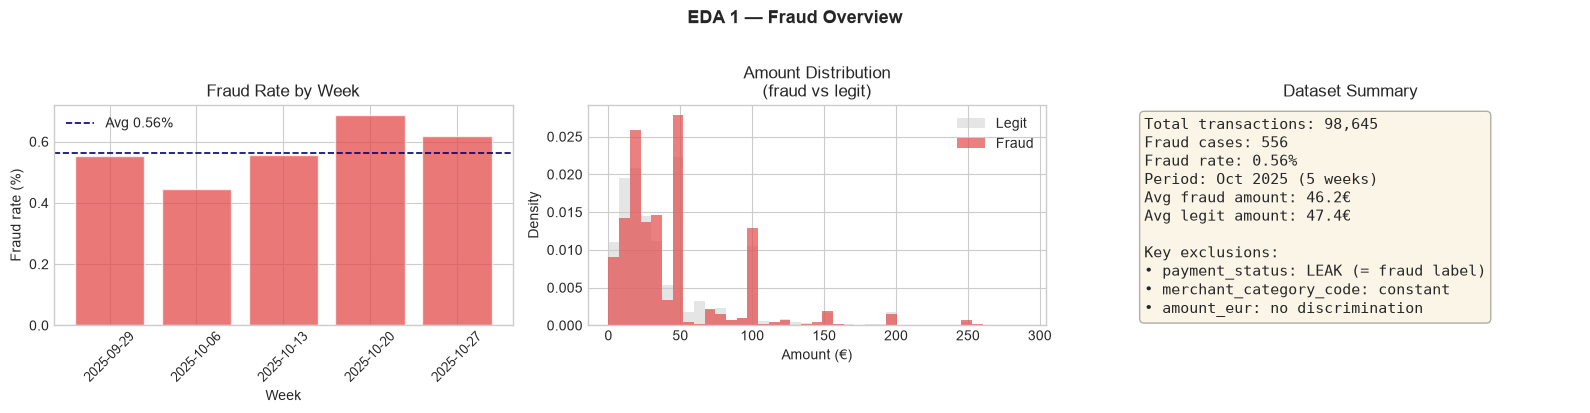

In [4]:

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs("../images", exist_ok=True)

baseline = df['fraud'].mean()
total_fraud = df['fraud'].sum()

# ── EDA 1: Fraud Overview ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1a. Fraud rate per settimana
weekly = df.groupby('week').agg(
    n_txn   = ('fraud', 'count'),
    n_fraud = ('fraud', 'sum'),
).assign(fraud_rate = lambda x: x['n_fraud'] / x['n_txn'])

ax = axes[0]
ax.bar(range(len(weekly)), weekly['fraud_rate']*100,
       color='#E24B4A', alpha=0.75, edgecolor='white')
ax.axhline(baseline*100, color='navy', ls='--', lw=1.2, label=f'Avg {baseline:.2%}')
ax.set_xlabel('Week')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Week')
ax.set_xticks(range(len(weekly)))
ax.set_xticklabels(weekly.index, rotation=45, fontsize=9)
ax.legend()

# 1b. Fraud per importo
ax = axes[1]
bins = np.linspace(0, df['amount_eur'].quantile(0.99), 40)
ax.hist(df[df['fraud']==0]['amount_eur'], bins=bins, alpha=0.5,
        color='#CCCCCC', density=True, label='Legit')
ax.hist(df[df['fraud']==1]['amount_eur'], bins=bins, alpha=0.7,
        color='#E24B4A', density=True, label='Fraud')
ax.set_xlabel('Amount (€)')
ax.set_ylabel('Density')
ax.set_title('Amount Distribution\n(fraud vs legit)')
ax.legend()

# 1c. Key numbers summary
ax = axes[2]
ax.axis('off')
summary_text = (
    f"Total transactions: {len(df):,}\n"
    f"Fraud cases: {total_fraud:,}\n"
    f"Fraud rate: {baseline:.2%}\n"
    f"Period: Oct 2025 (5 weeks)\n"
    f"Avg fraud amount: {df[df['fraud']==1]['amount_eur'].mean():.1f}€\n"
    f"Avg legit amount: {df[df['fraud']==0]['amount_eur'].mean():.1f}€\n"
    f"\nKey exclusions:\n"
    f"• payment_status: LEAK (= fraud label)\n"
    f"• merchant_category_code: constant\n"
    f"• amount_eur: no discrimination"
)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax.set_title('Dataset Summary')

plt.suptitle('EDA 1 — Fraud Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/eda1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA 2 — Tenure: The Dominant Fraud Signal

Account tenure is by far the strongest signal in the dataset. We compare the
age of fraudulent versus legitimate accounts and quantify how much fraud we
could capture by flagging young accounts.

**The pattern:** fraud comes from newly-created accounts (median ~31 days vs
~1,265 for legit — a 40x gap). This points to a *"register → defraud →
disappear"* behaviour: accounts created specifically to commit fraud, rather
than compromised long-standing accounts. The cumulative-recall curve shows
how blocking accounts below a tenure threshold trades coverage against the
number of legitimate customers affected.

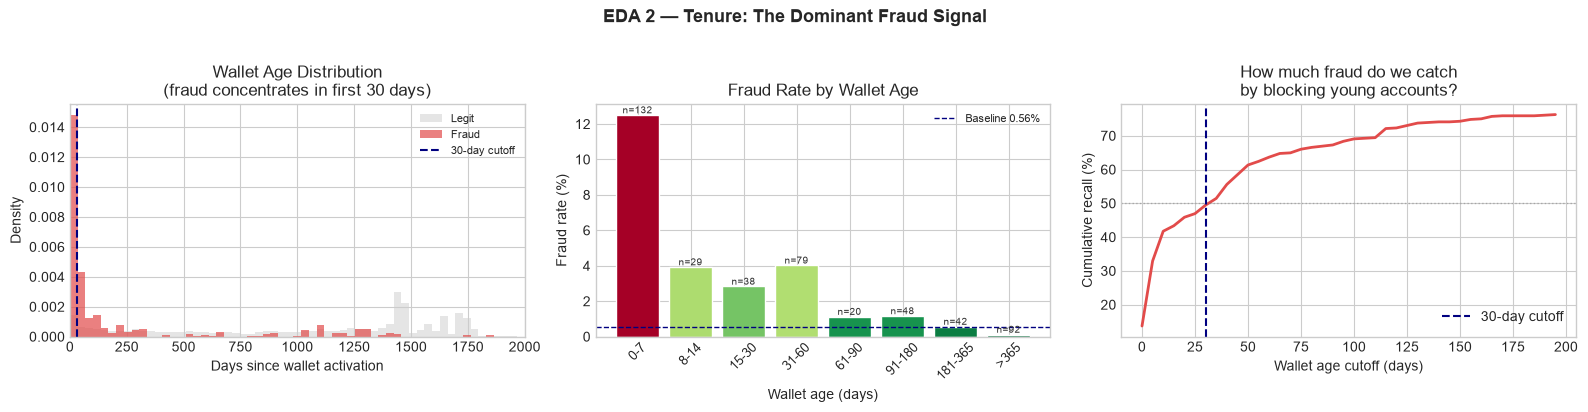

In [5]:
# ── EDA 2: Tenure — The Dominant Signal ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2a. Distribuzione tenure fraud vs legit (log scale)
ax = axes[0]
bins = np.linspace(0, 2000, 60)
ax.hist(df[df['fraud']==0]['days_since_wallet_activation'], bins=bins,
        alpha=0.5, color='#CCCCCC', density=True, label='Legit')
ax.hist(df[df['fraud']==1]['days_since_wallet_activation'], bins=bins,
        alpha=0.7, color='#E24B4A', density=True, label='Fraud')
ax.axvline(30, color='navy', ls='--', lw=1.5, label='30-day cutoff')
ax.set_xlabel('Days since wallet activation')
ax.set_ylabel('Density')
ax.set_title('Wallet Age Distribution\n(fraud concentrates in first 30 days)')
ax.set_xlim([0, 2000])
ax.legend(fontsize=8)

# 2b. Fraud rate per bucket di tenure
ax = axes[1]
tenure_bins = [0, 7, 14, 30, 60, 90, 180, 365, 9999]
tenure_labels = ['0-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '>365']
df['tenure_bucket'] = pd.cut(df['days_since_wallet_activation'], bins=tenure_bins,
                              labels=tenure_labels, right=True)
tb = df.groupby('tenure_bucket', observed=True).agg(
    fraud_rate = ('fraud', 'mean'),
    n_fraud    = ('fraud', 'sum'),
    n_txn      = ('fraud', 'count')
).reset_index()

colors = plt.cm.RdYlGn_r(tb['fraud_rate'] / tb['fraud_rate'].max())
bars = ax.bar(range(len(tb)), tb['fraud_rate']*100, color=colors, edgecolor='white')
ax.axhline(baseline*100, color='navy', ls='--', lw=1, label=f'Baseline {baseline:.2%}')
ax.set_xticks(range(len(tb)))
ax.set_xticklabels(tb['tenure_bucket'], rotation=45, fontsize=9)
ax.set_xlabel('Wallet age (days)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Wallet Age')
ax.legend(fontsize=8)

# Annota n_fraud sopra ogni barra
for i, row in tb.iterrows():
    if row['n_fraud'] > 0:
        ax.text(i, row['fraud_rate']*100 + 0.1, f"n={int(row['n_fraud'])}",
                ha='center', fontsize=7, color='#333')

# 2c. Recall cumulata: quante frodi catturo tagliando a X giorni?
ax = axes[2]
thresholds = range(0, 200, 5)
recalls = [df[df['days_since_wallet_activation'] <= t]['fraud'].sum() / total_fraud
           for t in thresholds]
ax.plot(thresholds, [r*100 for r in recalls], color='#E24B4A', lw=2)
ax.axhline(50, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(30, color='navy', ls='--', lw=1.5, label='30-day cutoff')
ax.set_xlabel('Wallet age cutoff (days)')
ax.set_ylabel('Cumulative recall (%)')
ax.set_title('How much fraud do we catch\nby blocking young accounts?')
ax.legend()

plt.suptitle('EDA 2 — Tenure: The Dominant Fraud Signal', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/eda2_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['tenure_bucket'], inplace=True)

### EDA 3 — Geography & Banking Signals

Beyond account tenure, fraud concentrates around specific geographic and
banking attributes. We rank regions and banks by fraud rate (filtered for
minimum volume to avoid small-sample noise) and test the IBAN/residence
country mismatch.

**What to look for:**
- **Regions & banks**: a subset show fraud rates 5-10x the baseline. These
  feed the `high_risk_region` and `high_risk_bank` features used later in
  rule design.
- **Country mismatch**: when the IBAN country differs from the residence
  country, the fraud rate is ~6x higher — a strong but narrow signal (it
  covers only ~9% of all fraud, since most fraud comes from young accounts
  with matching geography).

*Caveat on small samples*: some high-risk regions have few transactions, so
their fraud rate is statistically unstable. Rules should be built on segments
with sufficient volume, not on single low-count categories — a point we
revisit in rule design.

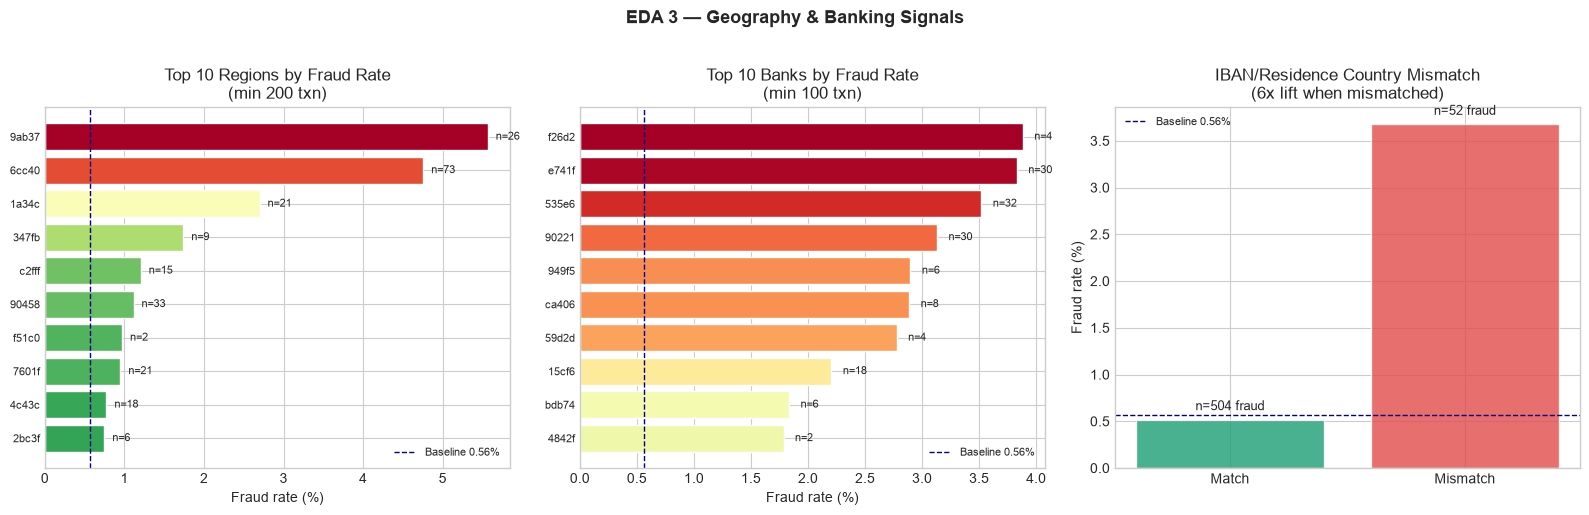

In [6]:
# ── EDA 3: Geography & Banking Signals ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# creo la colonna per country mismatch
if 'country_mismatch' not in df.columns:
    df['country_mismatch'] = (
        (df['residence_country'] != df['iban_country_code'])
        & df['iban_country_code'].notna()
    ).astype(int)

# 3a. Top regioni per fraud rate (min 200 txn)
ax = axes[0]
reg = df.groupby('residence_region')['fraud'].agg(['mean', 'sum', 'count'])
reg = reg[reg['count'] >= 200].sort_values('mean', ascending=True).tail(10)
colors_reg = plt.cm.RdYlGn_r(reg['mean'] / reg['mean'].max())
ax.barh(range(len(reg)), reg['mean']*100, color=colors_reg, edgecolor='white')
ax.set_yticks(range(len(reg)))
ax.set_yticklabels(reg.index, fontsize=8)
ax.axvline(baseline*100, color='navy', ls='--', lw=1, label=f'Baseline {baseline:.2%}')
ax.set_xlabel('Fraud rate (%)')
ax.set_title('Top 10 Regions by Fraud Rate\n(min 200 txn)')
for i, (idx, row) in enumerate(reg.iterrows()):
    ax.text(row['mean']*100 + 0.1, i, f"n={int(row['sum'])}", va='center', fontsize=8)
ax.legend(fontsize=8)

# 3b. Top banche per fraud rate (min 100 txn)
ax = axes[1]
bnk = df.groupby('bank_name')['fraud'].agg(['mean', 'sum', 'count'])
bnk = bnk[bnk['count'] >= 100].sort_values('mean', ascending=True).tail(10)
colors_bnk = plt.cm.RdYlGn_r(bnk['mean'] / bnk['mean'].max())
ax.barh(range(len(bnk)), bnk['mean']*100, color=colors_bnk, edgecolor='white')
ax.set_yticks(range(len(bnk)))
ax.set_yticklabels(bnk.index, fontsize=8)
ax.axvline(baseline*100, color='navy', ls='--', lw=1, label=f'Baseline {baseline:.2%}')
ax.set_xlabel('Fraud rate (%)')
ax.set_title('Top 10 Banks by Fraud Rate\n(min 100 txn)')
for i, (idx, row) in enumerate(bnk.iterrows()):
    ax.text(row['mean']*100 + 0.1, i, f"n={int(row['sum'])}", va='center', fontsize=8)
ax.legend(fontsize=8)

# 3c. Country mismatch
ax = axes[2]
cm = df.groupby('country_mismatch')['fraud'].agg(['mean', 'sum', 'count']).reset_index()
cm['label'] = cm['country_mismatch'].map({0: 'Match', 1: 'Mismatch'})
colors_cm = ['#1D9E75', '#E24B4A']
ax.bar(cm['label'], cm['mean']*100, color=colors_cm, alpha=0.8, edgecolor='white')
ax.axhline(baseline*100, color='navy', ls='--', lw=1, label=f'Baseline {baseline:.2%}')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('IBAN/Residence Country Mismatch\n(6x lift when mismatched)')
for i, row in cm.iterrows():
    ax.text(i, row['mean']*100 + 0.1, f"n={int(row['sum'])} fraud",
            ha='center', fontsize=9)
ax.legend(fontsize=8)

plt.suptitle('EDA 3 — Geography & Banking Signals', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/eda3_geography.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings Summary

The fraud in this dataset has a clear and coherent profile.

**The dominant pattern: fraud comes from newly-created accounts.**
The single strongest signal is account tenure. Fraudulent accounts have a
median age of ~31 days (wallet activation) versus ~1,265 days for legitimate
ones — a 40x difference. The story is *"register → defraud → disappear"*:
these are accounts created to commit fraud, not compromised legitimate
accounts. Tenure alone captures up to 67% of fraud.

**Amplifying signals: geography and banking.**
On top of tenure, fraud concentrates around specific regions (fraud rate
5-10x baseline), banks (5-7x), and IBAN countries (5-6x). The IBAN/residence
country mismatch carries a ~6x lift but is narrow (only ~9% of fraud) — most
fraud comes from young accounts whose geography is internally consistent.

**Signals that do NOT discriminate.**
- `amount_eur`: fraud and legit have near-identical medians (~31€ vs 30€) —
  fraud here is not about transaction size.
- `device_os`: negligible lift (~1x).

**Features excluded for rigour:**

| Feature | Reason for exclusion |
|---------|---------------------|
| `payment_status` | Outcome, not predictor — perfectly collinear with the target (all FAILED = fraud). |
| `merchant_category_code` | Constant (single value) — no information. |
| `last_payment_date` | Equals `created_date` for all rows — no information. |
| `amount_eur` | No discrimination between fraud and legit. |


# Challenge 2 — Risk Management

## Task 1 — Rule Design & Measurement

> *"Which rule(s) would you implement to minimize fraud losses? How do you
> plan to measure success post-rollout, and how would you prioritise?"*

We design rules progressively, from simple to systematic, then select the
optimal set by business value and define how to deploy and measure it.

Our goal is to find rules that minimize fraud losses while keeping false
positives manageable. We build up progressively, each step improving on
the previous one's limitations:

| Step | Approach | What it shows |
|------|----------|---------------|
| **1** | Single-feature threshold (tenure) | The dominant signal, but precision too low alone |
| **2** | Combined rules (tenure + geography/banking) | Interactions lift precision sharply |
| **3** | Decision tree | Finds optimal multivariate rules systematically |
| **4** | Greedy rule set | The standard approach — and why it fails (precision collapses) |
| **5** | Best subset by Net Value | Optimal set under a business cost model |
| **6** | Block / Alert / Shadow | Differentiated action per rule |
| **7** | Post-rollout measurement | KPIs, monitoring, prioritisation |

The final deliverable is a **rule set**: multiple complementary rules running
in parallel (OR logic), each covering a different fraud pattern, with a
defined action and a plan to measure success.

### Step 1: Single-feature threshold

,cutoff_days,flagged,caught,precision,recall,lift,fp
0,7,"2,775",208,7.5%,37.4%,13.3x,"2,567"
1,14,"3,514",237,6.7%,42.6%,12.0x,"3,277"
2,30,"4,857",275,5.7%,49.5%,10.0x,"4,582"
3,60,"6,822",354,5.2%,63.7%,9.2x,"6,468"
4,90,"8,599",374,4.3%,67.3%,7.7x,"8,225"
5,120,"10,198",402,3.9%,72.3%,7.0x,"9,796"
6,180,"12,725",422,3.3%,75.9%,5.9x,"12,303"


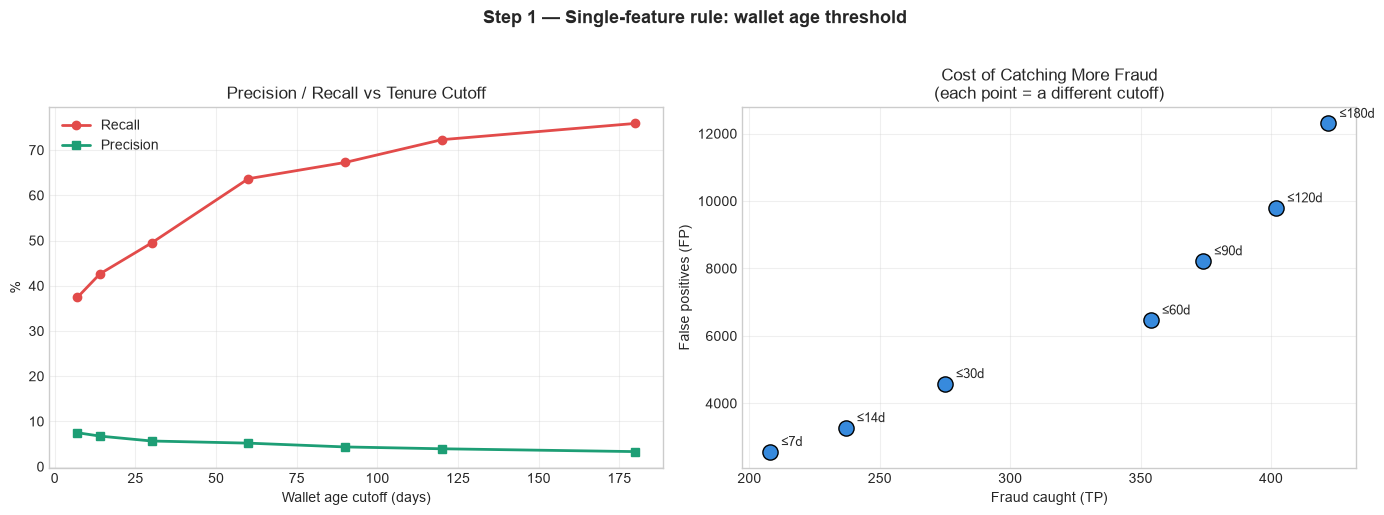

KEY FINDING:
  Tenure alone captures up to 67% of fraud (≤90d cutoff),
  but precision stays between 4-8% — for every fraud caught,
  we block ~17 legitimate customers.

  A single-feature threshold is too blunt to deploy as a block.
  → Step 2: can we improve precision by combining signals?


In [7]:

# -- Threshold sweep on wallet age ------------------------------------------- #

thresholds = [7, 14, 30, 60, 90, 120, 180]
rule_results = []

for t in thresholds:
    mask = df["days_since_wallet_activation"] <= t
    flagged = mask.sum()
    caught = int(df.loc[mask, "fraud"].sum())
    precision = caught / flagged if flagged > 0 else 0
    recall = caught / total_fraud

    rule_results.append({
        "cutoff_days": t,
        "flagged": flagged,
        "caught": caught,
        "precision": precision,
        "recall": recall,
        "lift": precision / baseline,
        "fp": flagged - caught,
    })

sweep_df = pd.DataFrame(rule_results)

# -- Display ----------------------------------------------------------------- #

display(
    sweep_df.style
    .format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "lift": "{:.1f}x",
        "flagged": "{:,}",
        "caught": "{:,}",
        "fp": "{:,}",
    })
    .set_caption(
        f"Tenure threshold sweep — baseline fraud rate: {baseline:.2%}"
    )
)

# -- Visualisation: precision vs recall trade-off ---------------------------- #

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: precision and recall vs cutoff
ax = axes[0]
ax.plot(sweep_df["cutoff_days"], sweep_df["recall"] * 100,
        marker="o", color="#E24B4A", lw=2, label="Recall")
ax.plot(sweep_df["cutoff_days"], sweep_df["precision"] * 100,
        marker="s", color="#1D9E75", lw=2, label="Precision")
ax.set_xlabel("Wallet age cutoff (days)")
ax.set_ylabel("%")
ax.set_title("Precision / Recall vs Tenure Cutoff")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: false positives vs fraud caught
ax = axes[1]
ax.scatter(sweep_df["caught"], sweep_df["fp"],
           s=120, c="#378ADD", edgecolors="black", zorder=3)
for _, row in sweep_df.iterrows():
    ax.annotate(f"≤{int(row['cutoff_days'])}d",
                (row["caught"], row["fp"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Fraud caught (TP)")
ax.set_ylabel("False positives (FP)")
ax.set_title("Cost of Catching More Fraud\n(each point = a different cutoff)")
ax.grid(True, alpha=0.3)

plt.suptitle("Step 1 — Single-feature rule: wallet age threshold",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../images/step1_tenure_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# -- Key takeaway ------------------------------------------------------------ #
print("KEY FINDING:")
print("  Tenure alone captures up to 67% of fraud (≤90d cutoff),")
print("  but precision stays between 4-8% — for every fraud caught,")
print(f"  we block ~{int(1/sweep_df.iloc[2]['precision'])} legitimate customers.")
print("\n  A single-feature threshold is too blunt to deploy as a block.")
print("  → Step 2: can we improve precision by combining signals?")

### Step 2 — Combining Signals

Step 1 showed tenure alone reaches up to 67% recall but precision stays at
4-8% — too blunt to block on. The hypothesis: combining tenure with the
geography and banking signals from EDA isolates the *truly* fraudulent subset
of young accounts, lifting precision sharply.

**Minimal feature engineering.** We derive two binary features from the EDA:
`high_risk_region` and `high_risk_bank`, flagging the regions and banks whose
fraud rate ran well above baseline. These group many sparse categories into a
single robust signal. One caveat: the high-risk lists are built on the full
sample, which introduces mild target leakage — in production they would be
derived from a past period and applied forward, then recalibrated periodically.
The underlying pattern (some regions and banks concentrate fraud) is stable;
only the exact membership would be refreshed over time.

We test combinations manually here to build intuition — Step 3 then lets a
decision tree find them systematically. The expected pattern: combinations
(AND logic) push precision up but cover a narrower slice of fraud (lower recall
per rule). This is why no single rule suffices, and why the final deliverable
is a *set* of complementary rules.

,rule,flagged,caught,precision,recall,lift,fp
0,Tenure ≤ 30d (baseline),"4,857",275,5.7%,49.5%,10.0x,"4,582"
1,Country mismatch (baseline),"1,414",52,3.7%,9.4%,6.5x,"1,362"
2,Tenure ≤ 30d AND country mismatch,115,29,25.2%,5.2%,44.7x,86
3,Tenure ≤ 30d AND high-risk region,421,68,16.2%,12.2%,28.7x,353
4,Tenure ≤ 30d AND high-risk bank,267,54,20.2%,9.7%,35.9x,213
5,Tenure ≤ 60d AND country mismatch,157,32,20.4%,5.8%,36.2x,125
6,Tenure ≤ 60d AND high-risk region,670,116,17.3%,20.9%,30.7x,554
7,Tenure ≤ 60d AND high-risk region AND low activity,588,68,11.6%,12.2%,20.5x,520


findfont: Failed to find font weight medium, now using 400.


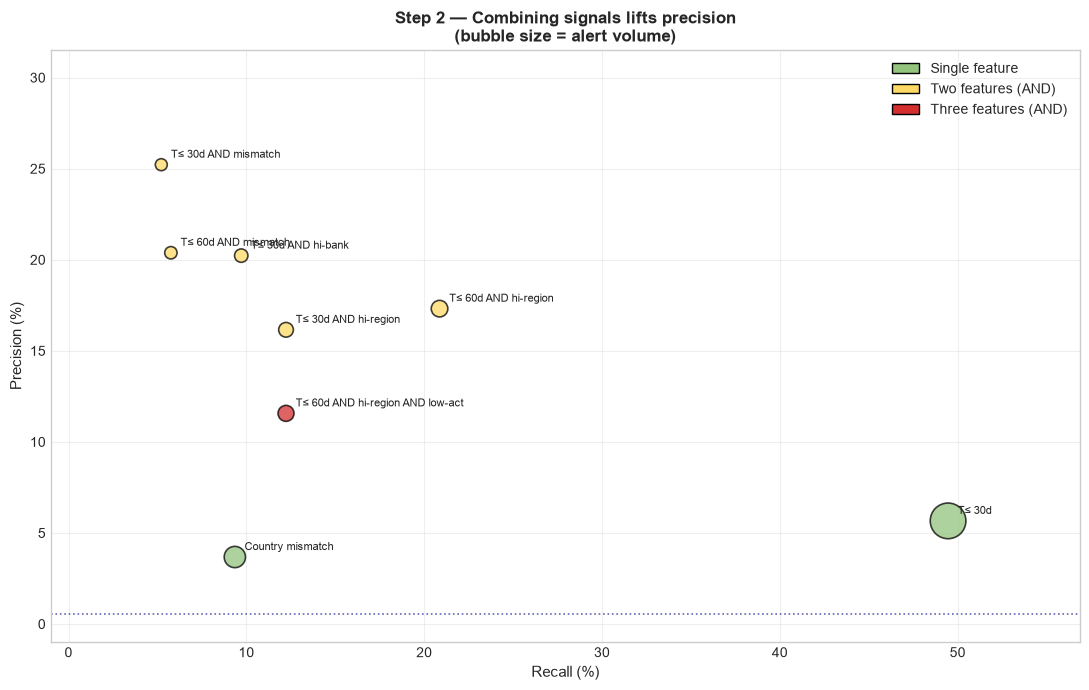

KEY FINDING:
  Best single rule:   precision 5.7%, recall 49.5%
  Best combination:   precision 25.2%, recall 5.2%
  → Precision jumps 4x by combining signals

  But each combination covers a narrow slice of fraud.
  No single combined rule catches more than ~10-15% of all fraud.

  → Step 3: decision tree finds optimal partitions systematically,
    then we COMBINE multiple rules (OR) for coverage.


In [8]:
# ==============================================================================
# Step 2: Combined rules (tenure + geography / banking)
# ==============================================================================
# Step 1 showed that tenure alone has recall up to 67% but precision stays
# at 4-8%. The hypothesis: combining tenure with geography or banking signals
# isolates the truly fraudulent subset of young accounts, boosting precision
# while accepting lower recall per rule.
#
# We test combinations manually to build intuition before letting the
# decision tree find them systematically in Step 3.

# -- Define candidate combinations ------------------------------------------- #

# High-risk regions identified in EDA 3 (lift > 3x, min 200 txn)
high_risk_regions = ["9ab37", "6cc40", "1a34c", "347fb"]
df["high_risk_region"] = df["residence_region"].isin(high_risk_regions).astype(int)

# High-risk banks identified in EDA 3 (lift > 5x, min 100 txn)
high_risk_banks = ["e741f", "535e6", "90221", "f26d2", "949f5", "ca406"]
df["high_risk_bank"] = df["bank_name"].isin(high_risk_banks).astype(int)

rules = {
    # Single-feature baselines (from Step 1)
    "Tenure ≤ 30d (baseline)":
        df["days_since_wallet_activation"] <= 30,

    "Country mismatch (baseline)":
        df["country_mismatch"] == 1,

    # Two-feature combinations: tenure + one signal
    "Tenure ≤ 30d  AND  country mismatch":
        (df["days_since_wallet_activation"] <= 30) & (df["country_mismatch"] == 1),

    "Tenure ≤ 30d  AND  high-risk region":
        (df["days_since_wallet_activation"] <= 30) & (df["high_risk_region"] == 1),

    "Tenure ≤ 30d  AND  high-risk bank":
        (df["days_since_wallet_activation"] <= 30) & (df["high_risk_bank"] == 1),

    "Tenure ≤ 60d  AND  country mismatch":
        (df["days_since_wallet_activation"] <= 60) & (df["country_mismatch"] == 1),

    "Tenure ≤ 60d  AND  high-risk region":
        (df["days_since_wallet_activation"] <= 60) & (df["high_risk_region"] == 1),

    # Three-feature combination
    "Tenure ≤ 60d  AND  high-risk region  AND  low activity":
        (df["days_since_wallet_activation"] <= 60)
        & (df["high_risk_region"] == 1)
        & (df["payment_to_business_count_lifetime"] <= 20),
}

# -- Evaluate all rules ------------------------------------------------------ #

combo_results = []
for name, mask in rules.items():
    flagged = mask.sum()
    caught = int(df.loc[mask, "fraud"].sum())
    precision = caught / flagged if flagged > 0 else 0
    recall = caught / total_fraud
    combo_results.append({
        "rule": name,
        "flagged": flagged,
        "caught": caught,
        "precision": precision,
        "recall": recall,
        "lift": precision / baseline,
        "fp": flagged - caught,
    })

combo_df = pd.DataFrame(combo_results)

display(
    combo_df.style
    .format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "lift": "{:.1f}x",
        "flagged": "{:,}",
        "caught": "{:,}",
        "fp": "{:,}",
    })
    .set_caption("Step 2 — Combined rules: precision improves dramatically")
)

# -- Visualisation: single vs combined in precision-recall plane ------------- #

fig, ax = plt.subplots(figsize=(11, 7))

# Vivid colors by rule type
def rule_color(name):
    if "baseline" in name:
        return "#93C47D"               # grey — single feature
    if name.count("AND") >= 2:
        return "#D32F2F"               # strong red — three features
    return "#FFD966"                   # strong blue — two features

colors = [rule_color(n) for n in combo_df["rule"]]

# Bubble size: scale precision-recall point by alert volume, but clamp range
sizes = 60 + (combo_df["flagged"] / combo_df["flagged"].max()) * 600

scatter = ax.scatter(
    combo_df["recall"] * 100, combo_df["precision"] * 100,
    s=sizes, c=colors, edgecolors="black", linewidth=1.2,
    alpha=0.75, zorder=3,
)

# Labels with offset, shortened
texts = []
for _, row in combo_df.iterrows():
    short = (row["rule"]
             .replace(" (baseline)", "")
             .replace("Tenure ", "T")
             .replace("country mismatch", "mismatch")
             .replace("high-risk ", "hi-")
             .replace("low activity", "low-act")
             .replace("  ", " "))
    texts.append(
        ax.annotate(
            short,
            (row["recall"] * 100, row["precision"] * 100),
            fontsize=8, color="#222", fontweight="medium",
            xytext=(7, 5), textcoords="offset points",
        )
    )

# Try to auto-separate overlapping labels if adjustText is available
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
except ImportError:
    pass  # labels keep manual offset if library not installed

ax.axhline(baseline * 100, color="navy", ls=":", lw=1.2, alpha=0.6,
           label=f"Baseline precision ({baseline:.2%})")

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#93C47D", edgecolor="black", label="Single feature"),
    Patch(facecolor="#FFD966", edgecolor="black", label="Two features (AND)"),
    Patch(facecolor="#D32F2F", edgecolor="black", label="Three features (AND)"),
]
ax.legend(handles=legend_elems, loc="upper right", framealpha=0.95)

ax.set_xlabel("Recall (%)", fontsize=11)
ax.set_ylabel("Precision (%)", fontsize=11)
ax.set_title("Step 2 — Combining signals lifts precision\n"
             "(bubble size = alert volume)", fontsize=12, fontweight="bold")
ax.set_ylim([-1, max(combo_df["precision"] * 100) * 1.25])
ax.set_xlim([-1, max(combo_df["recall"] * 100) * 1.15])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/step2_combined_rules.png", dpi=150, bbox_inches="tight")
plt.show()

# -- Key takeaway (robust label lookup) -------------------------------------- #
best = combo_df.loc[combo_df["precision"].idxmax()]
base = combo_df[combo_df["rule"] == "Tenure ≤ 30d (baseline)"].iloc[0]

print("KEY FINDING:")
print(f"  Best single rule:   precision {base['precision']:.1%}, recall {base['recall']:.1%}")
print(f"  Best combination:   precision {best['precision']:.1%}, recall {best['recall']:.1%}")
print(f"  → Precision jumps {best['precision']/base['precision']:.0f}x by combining signals")
print(f"\n  But each combination covers a narrow slice of fraud.")
print("  No single combined rule catches more than ~10-15% of all fraud.")
print("\n  → Step 3: decision tree finds optimal partitions systematically,")
print("    then we COMBINE multiple rules (OR) for coverage.")

### Step 3: Systematic Rule Discovery via Decision Tree

Steps 1-2 showed that combining signals lifts precision, but exploring
combinations by hand does not scale. A shallow decision tree finds the
optimal multivariate partitions automatically: each leaf is a rule defined
by the path from root to leaf (a conjunction of IF-THEN conditions).

**Why cost-sensitive sampling.** At a 0.56% fraud rate, Gini impurity is
near-zero everywhere, so a tree trained on raw data won't split on
fraud-relevant features — it optimises overall classification, not fraud
concentration. We train on a 50/50 resampled dataset (where every
fraud-specific split is rewarded), then evaluate each leaf on the real
distribution to recover honest precision and recall.

**Two refinements** for cleaner, more defensible rules:
1. We drop `days_since_first_payment` (highly correlated with wallet age)
   so the tree is forced to use the diverse geography/banking signals from
   EDA rather than splitting repeatedly on tenure.
2. We simplify redundant conditions — a tree may split on the same feature
   twice (`x <= 125 AND x <= 55`), which collapses to `x <= 55`.

Resampled training set: 10,000 rows, 50% fraud (artificial)
Real dataset for evaluation: 98,645 rows, 0.56% fraud (true)



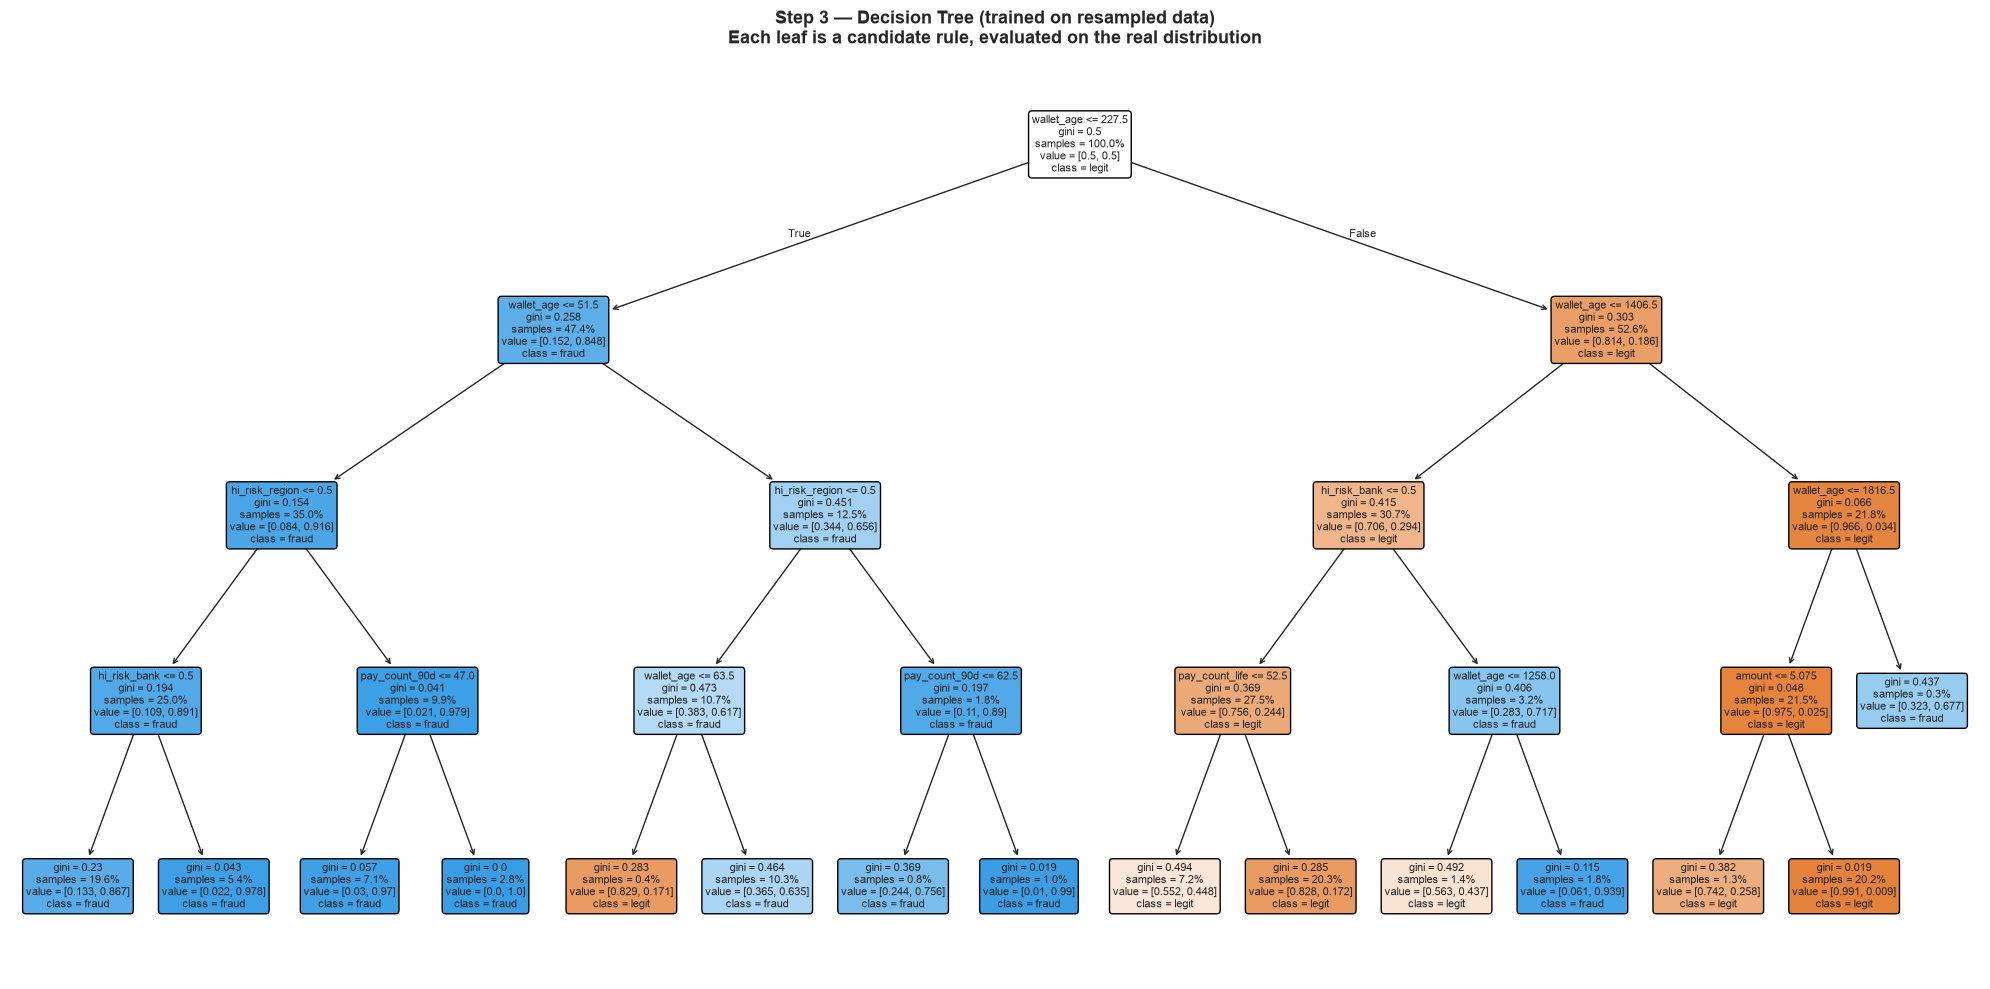

Rules extracted (after simplification & dedup): 15
Rules above baseline: 10



,rule_id,rule_text,flagged,caught,fp,precision,recall,lift
0,R1,wallet_age <= 52 AND pay_count_90d > 47 AND hi_risk_region > 0,31,31,0,100.0%,5.6%,177.4x
1,R2,52 < wallet_age <= 228 AND pay_count_90d > 62 AND hi_risk_region > 0,30,14,16,46.7%,2.5%,82.8x
2,R3,hi_risk_bank > 0 AND wallet_age <= 52 AND hi_risk_region <= 0,288,52,236,18.1%,9.4%,32.0x
3,R4,wallet_age <= 52 AND pay_count_90d <= 47 AND hi_risk_region > 0,583,74,509,12.7%,13.3%,22.5x
4,R5,hi_risk_bank > 0 AND 1258 < wallet_age <= 1406,257,20,237,7.8%,3.6%,13.8x
5,R6,hi_risk_bank <= 0 AND wallet_age <= 52 AND hi_risk_region <= 0,"5,402",186,"5,216",3.4%,33.5%,6.1x
6,R7,52 < wallet_age <= 228 AND pay_count_90d <= 62 AND hi_risk_region > 0,480,7,473,1.5%,1.3%,2.6x
7,R8,64 < wallet_age <= 228 AND hi_risk_region <= 0,"7,074",76,"6,998",1.1%,13.7%,1.9x
8,R9,wallet_age > 1816,285,2,283,0.7%,0.4%,1.2x
9,R10,hi_risk_bank > 0 AND 228 < wallet_age <= 1258,"1,249",8,"1,241",0.6%,1.4%,1.1x


In [9]:

# -- Feature preparation ----------------------------------------------------- #
# Note: days_since_first_payment dropped (redundant with wallet_age)

FEATURES = [
    "days_since_wallet_activation",
    "payment_to_business_count_lifetime",
    "payment_to_business_count_90d",
    "amount_eur",
    "country_mismatch",
    "high_risk_region",
    "high_risk_bank",
]

FEATURE_LABELS = {
    "days_since_wallet_activation": "wallet_age",
    "payment_to_business_count_lifetime": "pay_count_life",
    "payment_to_business_count_90d": "pay_count_90d",
    "amount_eur": "amount",
    "country_mismatch": "country_mm",
    "high_risk_region": "hi_risk_region",
    "high_risk_bank": "hi_risk_bank",
}

X = df[FEATURES].fillna(-1)
y = df["fraud"]

# -- Cost-sensitive sampling ------------------------------------------------- #

np.random.seed(42)
fraud_idx = df[df["fraud"] == 1].index
legit_idx = df[df["fraud"] == 0].index

n_sample = 5000
fraud_sample = np.random.choice(fraud_idx, size=n_sample, replace=True)
legit_sample = np.random.choice(legit_idx, size=n_sample, replace=True)
sample_idx = np.concatenate([fraud_sample, legit_sample])

X_train = X.loc[sample_idx]
y_train = y.loc[sample_idx]

print(f"Resampled training set: {len(X_train):,} rows, "
      f"{y_train.mean():.0%} fraud (artificial)")
print(f"Real dataset for evaluation: {len(df):,} rows, "
      f"{baseline:.2%} fraud (true)\n")

# -- Train shallow decision tree --------------------------------------------- #

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=42,
)
dt.fit(X_train, y_train)

# -- Visualise the tree ------------------------------------------------------ #

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=[FEATURE_LABELS.get(f, f) for f in FEATURES],
    class_names=["legit", "fraud"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    proportion=True,
)
ax.set_title("Step 3 — Decision Tree (trained on resampled data)\n"
             "Each leaf is a candidate rule, evaluated on the real distribution",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/step3_decision_tree.png", dpi=200, bbox_inches="tight")
plt.show()


# -- Condition simplification ------------------------------------------------ #

def simplify_conditions(path):
    """Collapse multiple splits on the same feature into a single range."""
    upper, lower = {}, {}
    for feat, op, thresh in path:
        if op == "<=":
            if feat not in upper or thresh < upper[feat]:
                upper[feat] = thresh
        else:
            if feat not in lower or thresh > lower[feat]:
                lower[feat] = thresh

    simplified = []
    for feat in set(list(upper.keys()) + list(lower.keys())):
        if feat in lower and feat in upper:
            simplified.append((feat, "range", (lower[feat], upper[feat])))
        elif feat in upper:
            simplified.append((feat, "<=", upper[feat]))
        else:
            simplified.append((feat, ">", lower[feat]))
    return simplified


def condition_to_text(feat, op, thresh):
    """Human-readable condition string."""
    label = FEATURE_LABELS.get(feat, feat)
    if op == "range":
        return f"{thresh[0]:.0f} < {label} <= {thresh[1]:.0f}"
    return f"{label} {op} {thresh:.0f}"


def apply_simplified(df_real, conditions):
    """Apply simplified conditions, return boolean mask."""
    mask = pd.Series(True, index=df_real.index)
    for feat, op, thresh in conditions:
        if op == "<=":
            mask &= df_real[feat] <= thresh
        elif op == ">":
            mask &= df_real[feat] > thresh
        else:  # range
            mask &= (df_real[feat] > thresh[0]) & (df_real[feat] <= thresh[1])
    return mask


# -- Extract, simplify, and evaluate rules on REAL distribution -------------- #

def extract_rules(dt, feature_names, df_real, y_real, baseline):
    tree = dt.tree_
    rules = []

    def recurse(node, path):
        if tree.children_left[node] == _tree.TREE_LEAF:
            if len(path) == 0:
                return
            conditions = simplify_conditions(path)
            mask = apply_simplified(df_real, conditions)
            n = int(mask.sum())
            tp = int(y_real[mask].sum())
            if n == 0 or tp == 0:
                return
            rules.append({
                "conditions": conditions,
                "rule_text": " AND ".join(
                    condition_to_text(f, o, t) for f, o, t in conditions
                ),
                "n_conditions": len(conditions),
                "flagged": n,
                "caught": tp,
                "fp": n - tp,
                "precision": tp / n,
                "recall": tp / int(y_real.sum()),
                "lift": (tp / n) / baseline,
            })
        else:
            feat = feature_names[tree.feature[node]]
            thresh = tree.threshold[node]
            recurse(tree.children_left[node], path + [(feat, "<=", thresh)])
            recurse(tree.children_right[node], path + [(feat, ">", thresh)])

    recurse(0, [])
    return pd.DataFrame(rules)


rules_df = extract_rules(dt, FEATURES, X, y, baseline)
rules_df = rules_df.sort_values("precision", ascending=False).reset_index(drop=True)

# Deduplicate identical simplified rules
rules_df = rules_df.drop_duplicates(subset="rule_text").reset_index(drop=True)
rules_df["rule_id"] = [f"R{i+1}" for i in range(len(rules_df))]

print(f"Rules extracted (after simplification & dedup): {len(rules_df)}")
print(f"Rules above baseline: {(rules_df['precision'] > baseline).sum()}\n")

display(
    rules_df[rules_df["precision"] > baseline]
    [["rule_id", "rule_text", "flagged", "caught", "fp",
      "precision", "recall", "lift"]]
    .style.format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "lift": "{:.1f}x",
        "flagged": "{:,}",
        "caught": "{:,}",
        "fp": "{:,}",
    })
    .set_caption("Decision tree rules — simplified, evaluated on real distribution")
)

### Robustness check — Sensitivity to resampling size

The resampling size (`n_sample`) is a hyperparameter, and choosing a single
value is somewhat arbitrary. We check whether our rules depend on it.

**The test:** we re-run the rule extraction across a range of `n_sample`
values and group the resulting rules by *pattern* — which features they use
and in which direction — ignoring the exact thresholds (which naturally vary
a few points between runs).

**What we expect:** the dominant fraud patterns should appear regardless of
`n_sample`, while spurious rules appear in only one configuration. Confidence
belongs to the stable patterns, not the precise thresholds.

A more systematic framework would generate a rule pool across a range of
configurations and select by business value — keeping the patterns that
prove stable across settings, rather than relying on a single configuration.

In [10]:
# ── Robustness note: sensitivity to resampling size ──────────────────────────
# A side-check on the decision tree: the resampling size (n_sample) is an
# arbitrary choice. We verify the patterns it finds don't depend on it.

def rule_signature(conditions):
    parts = []
    for feat, op, _ in conditions:
        direction = "≤" if op == "<=" else (">" if op == ">" else "range")
        parts.append(f"{FEATURE_LABELS.get(feat, feat)} {direction}")
    return " & ".join(sorted(parts))


def extract_signatures(dt, feature_names, df_real, y_real, baseline):
    tree = dt.tree_
    sigs = set()
    def recurse(node, path):
        if tree.children_left[node] == _tree.TREE_LEAF:
            if path:
                conditions = simplify_conditions(path)
                mask = apply_simplified(df_real, conditions)
                n, tp = int(mask.sum()), int(y_real[mask].sum())
                if n > 0 and tp > 0 and (tp / n) > baseline:
                    sigs.add(rule_signature(conditions))
        else:
            feat = feature_names[tree.feature[node]]
            thresh = tree.threshold[node]
            recurse(tree.children_left[node], path + [(feat, "<=", thresh)])
            recurse(tree.children_right[node], path + [(feat, ">", thresh)])
    recurse(0, [])
    return sigs


N_SAMPLES = [2000, 5000, 8000, 12000, 20000]
pattern_counts = {}
for ns in N_SAMPLES:
    np.random.seed(42)
    fs = np.random.choice(fraud_idx, size=ns, replace=True)
    ls = np.random.choice(legit_idx, size=ns, replace=True)
    dt_s = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
    dt_s.fit(X.loc[np.concatenate([fs, ls])], y.loc[np.concatenate([fs, ls])])
    for s in extract_signatures(dt_s, FEATURES, X, y, baseline):
        pattern_counts[s] = pattern_counts.get(s, 0) + 1

stability_df = (
    pd.DataFrame([{"pattern": k,
                   "n_configs": v,                        # numeric — used by Step 6
                   "configs": f"{v}/{len(N_SAMPLES)}"}     # string — for display
                  for k, v in pattern_counts.items()])
    .sort_values("n_configs", ascending=False)
    .reset_index(drop=True)
)

# Show only the patterns that persist (≥2 configs) — the rest is one-off noise
n_robust = sum(1 for v in pattern_counts.values() if v >= 4)
n_total = len(pattern_counts)

display(
    stability_df[["pattern", "configs"]].head(6).style.set_caption(
        f"Pattern stability across resampling sizes "
        f"({n_robust} of {n_total} patterns appear in ≥4/5 configurations)"
    )
)

print("The dominant patterns persist regardless of n_sample; only minor ones "
      "flicker in and out. Exact thresholds vary, but which features matter — "
      "and in which direction — does not.")

,pattern,configs
0,hi_risk_region > & pay_count_90d > & wallet_age ≤,4/5
1,hi_risk_region > & pay_count_90d ≤ & wallet_age ≤,4/5
2,hi_risk_region ≤ & wallet_age ≤,3/5
3,hi_risk_region > & pay_count_90d ≤ & wallet_age range,2/5
4,hi_risk_bank > & wallet_age range,2/5
5,pay_count_life > & wallet_age range,2/5


The dominant patterns persist regardless of n_sample; only minor ones flicker in and out. Exact thresholds vary, but which features matter — and in which direction — does not.


### Step 4: Building the Rule Set

Individual rules each cover a slice of fraud. R1 is surgical (100% precision
but only 5.6% recall); R6 is broad (33.5% recall but 3.4% precision). No
single rule is enough.

In production we deploy a **rule set**: multiple rules running in parallel
(OR logic). A transaction is flagged if it satisfies *at least one* rule.

**How we build it — greedy forward selection:**
- Start empty, add the rule catching the most fraud
- At each step, add the rule that catches the most *new* fraud
  (fraud not already covered by rules in the set)
- Coverage is recomputed via OR of masks on the real data — never by
  summing recalls (that would double-count fraud caught by multiple rules)

**What to expect:** recall grows with each rule (we cover more fraud) but
with diminishing returns; precision tends to fall (each rule adds its own
false positives). The result is a curve of trade-offs.

**Where to stop** is a business decision — it depends on the relative cost
of a false positive (friction on a legitimate new customer) versus a false
negative (fraud loss). This links directly to the KPI defined in Challenge 1.

,step,rule_added,flagged,caught,fp,precision,recall,new_fraud
0,1,R6,"5,402",186,"5,216",3.4%,33.5%,186
1,2,R8,"12,476",262,"12,214",2.1%,47.1%,76
2,3,R4,"13,059",336,"12,723",2.6%,60.4%,74
3,4,R3,"13,347",388,"12,959",2.9%,69.8%,52
4,5,R1,"13,378",419,"12,959",3.1%,75.4%,31
5,6,R5,"13,635",439,"13,196",3.2%,79.0%,20
6,7,R2,"13,665",453,"13,212",3.3%,81.5%,14
7,8,R10,"14,914",461,"14,453",3.1%,82.9%,8
8,9,R7,"15,394",468,"14,926",3.0%,84.2%,7
9,10,R9,"15,679",470,"15,209",3.0%,84.5%,2


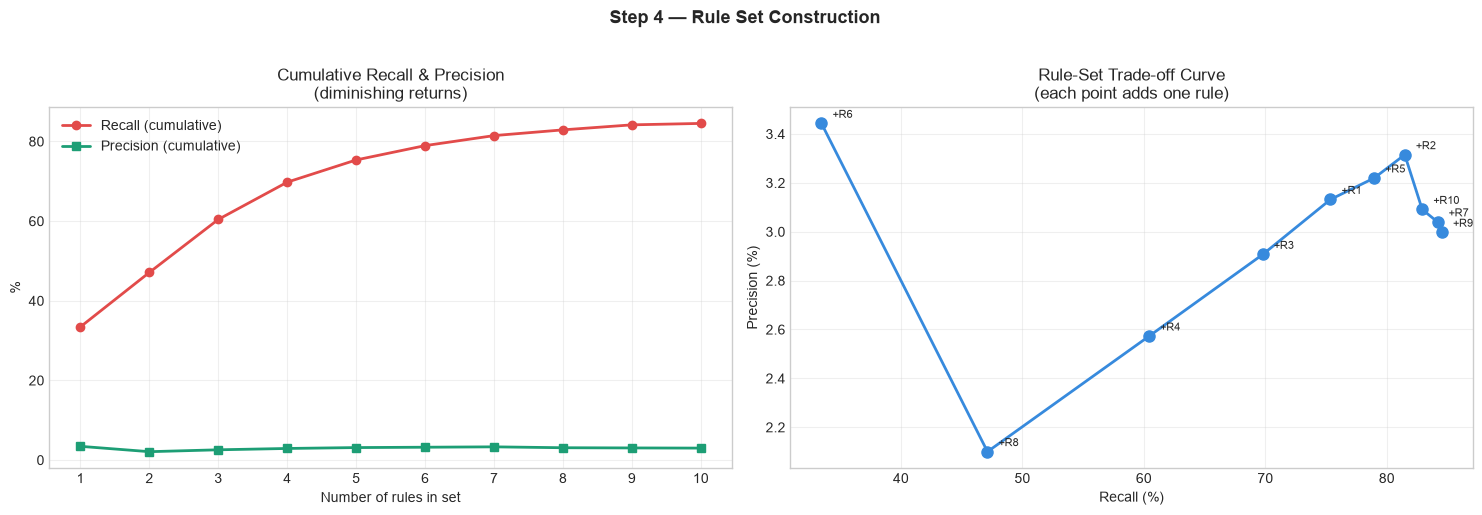

KEY FINDING:
  1 rule(s): recall 33.5%, precision 3.4% (+186 new fraud from R6)
  2 rule(s): recall 47.1%, precision 2.1% (+76 new fraud from R8)
  3 rule(s): recall 60.4%, precision 2.6% (+74 new fraud from R4)
  4 rule(s): recall 69.8%, precision 2.9% (+52 new fraud from R3)
  5 rule(s): recall 75.4%, precision 3.1% (+31 new fraud from R1)
  6 rule(s): recall 79.0%, precision 3.2% (+20 new fraud from R5)
  7 rule(s): recall 81.5%, precision 3.3% (+14 new fraud from R2)
  8 rule(s): recall 82.9%, precision 3.1% (+8 new fraud from R10)
  9 rule(s): recall 84.2%, precision 3.0% (+7 new fraud from R7)
  10 rule(s): recall 84.5%, precision 3.0% (+2 new fraud from R9)


In [11]:
# ==============================================================================
# Step 4: Rule set construction via greedy forward selection
# ==============================================================================

# Keep only rules above baseline as candidates
candidates = rules_df[rules_df["precision"] > baseline].copy().reset_index(drop=True)

# Pre-compute each rule's mask on the real dataset
rule_masks = {
    row["rule_id"]: apply_simplified(df, row["conditions"]).values
    for _, row in candidates.iterrows()
}

y_arr = df["fraud"].values
total_fraud = int(y_arr.sum())

# -- Greedy forward selection ------------------------------------------------ #

remaining = list(candidates["rule_id"])
selected = []
current_mask = np.zeros(len(df), dtype=bool)
sequence = []

while remaining:
    best_rule, best_new_fraud, best_mask = None, -1, None

    for rid in remaining:
        candidate_mask = current_mask | rule_masks[rid]
        new_fraud = (
            (candidate_mask & (y_arr == 1)).sum()
            - (current_mask & (y_arr == 1)).sum()
        )
        if new_fraud > best_new_fraud:
            best_new_fraud = new_fraud
            best_rule = rid
            best_mask = candidate_mask

    selected.append(best_rule)
    remaining.remove(best_rule)
    current_mask = best_mask

    flagged = int(current_mask.sum())
    caught = int((current_mask & (y_arr == 1)).sum())
    sequence.append({
        "step": len(selected),
        "rule_added": best_rule,
        "set_size": len(selected),
        "flagged": flagged,
        "caught": caught,
        "fp": flagged - caught,
        "precision": caught / flagged if flagged else 0,
        "recall": caught / total_fraud,
        "new_fraud": best_new_fraud,
    })

seq_df = pd.DataFrame(sequence)

display(
    seq_df[["step", "rule_added", "flagged", "caught", "fp",
            "precision", "recall", "new_fraud"]]
    .style.format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "flagged": "{:,}",
        "caught": "{:,}",
        "fp": "{:,}",
    })
    .set_caption("Greedy rule-set construction — cumulative coverage")
)

# -- Visualisation ----------------------------------------------------------- #

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: cumulative precision and recall vs set size
ax = axes[0]
ax.plot(seq_df["set_size"], seq_df["recall"] * 100,
        marker="o", color="#E24B4A", lw=2, label="Recall (cumulative)")
ax.plot(seq_df["set_size"], seq_df["precision"] * 100,
        marker="s", color="#1D9E75", lw=2, label="Precision (cumulative)")
ax.set_xlabel("Number of rules in set")
ax.set_ylabel("%")
ax.set_title("Cumulative Recall & Precision\n(diminishing returns)")
ax.set_xticks(seq_df["set_size"])
ax.legend()
ax.grid(True, alpha=0.3)

# Right: trade-off in precision-recall plane
ax = axes[1]
ax.plot(seq_df["recall"] * 100, seq_df["precision"] * 100,
        marker="o", color="#378ADD", lw=2, markersize=8)
for _, row in seq_df.iterrows():
    ax.annotate(f"+{row['rule_added']}",
                (row["recall"] * 100, row["precision"] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=8)
ax.set_xlabel("Recall (%)")
ax.set_ylabel("Precision (%)")
ax.set_title("Rule-Set Trade-off Curve\n(each point adds one rule)")
ax.grid(True, alpha=0.3)

plt.suptitle("Step 4 — Rule Set Construction",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/step4_rule_set.png", dpi=150, bbox_inches="tight")
plt.show()

# -- Key takeaway ------------------------------------------------------------ #
print("KEY FINDING:")
for _, row in seq_df.iterrows():
    print(f"  {row['set_size']} rule(s): recall {row['recall']:.1%}, "
          f"precision {row['precision']:.1%} "
          f"(+{row['new_fraud']} new fraud from {row['rule_added']})")

### Step 5: Optimal Rule Set via Business Value

Step 4 exposed the flaw of greedy selection: it maximizes fraud caught
while ignoring false positives. The result flags 16% of all transactions
to catch 85% of fraud — operationally unacceptable. Precision collapses
to ~3% because the greedy keeps adding broad, noisy rules.

The problem is that **recall and precision are not the real objective** —
the real objective is business value. Catching a fraud is worth the loss
it prevents; a false positive costs a manual review plus the friction of
blocking a legitimate customer.

We introduce a **cost model** and evaluate **every possible combination**
of the candidate rules (best subset selection — feasible here with few
rules), selecting the set that maximizes net value:

**Net Value** = (fraud caught × avg_fraud_loss) − (false positives × cost_per_false_positive)


Cost model: fraud caught = +50€, false positive = −5€  (ratio 10:1)

Combinations evaluated: 1,023



,rules,size,tp,fp,precision,recall,net_value
0,R1 + R2 + R3 + R4,4,171,761,18.3%,30.8%,"4,745€"
1,R1 + R2 + R3 + R4 + R5,5,191,998,16.1%,34.4%,"4,560€"
2,R1 + R3 + R4,3,157,745,17.4%,28.2%,"4,125€"
3,R1 + R3 + R4 + R5,4,177,982,15.3%,31.8%,"3,940€"
4,R1 + R2 + R3,3,97,252,27.8%,17.4%,"3,590€"
5,R1 + R2 + R3 + R4 + R9,5,173,"1,044",14.2%,31.1%,"3,430€"
6,R1 + R2 + R3 + R5,4,117,489,19.3%,21.0%,"3,405€"
7,R1 + R2 + R4,3,119,525,18.5%,21.4%,"3,325€"
8,R1 + R2 + R3 + R4 + R5 + R9,6,193,"1,281",13.1%,34.7%,"3,245€"
9,R2 + R3 + R4,3,140,761,15.5%,25.2%,"3,195€"


OPTIMAL RULE SET (max Net Value):
  Rules: R1 + R2 + R3 + R4
  Net Value: 4,745€
  Precision: 18.3% | Recall: 30.8%
  Catches 171 fraud, 761 false positives

Greedy full set (all rules): Net Value -52,545€ (precision 3.0%, recall 84.5%)
Best subset improves Net Value by 57,290€
→ The optimal set excludes broad, noisy rules whose false-positive
  cost exceeds the value of the fraud they catch.


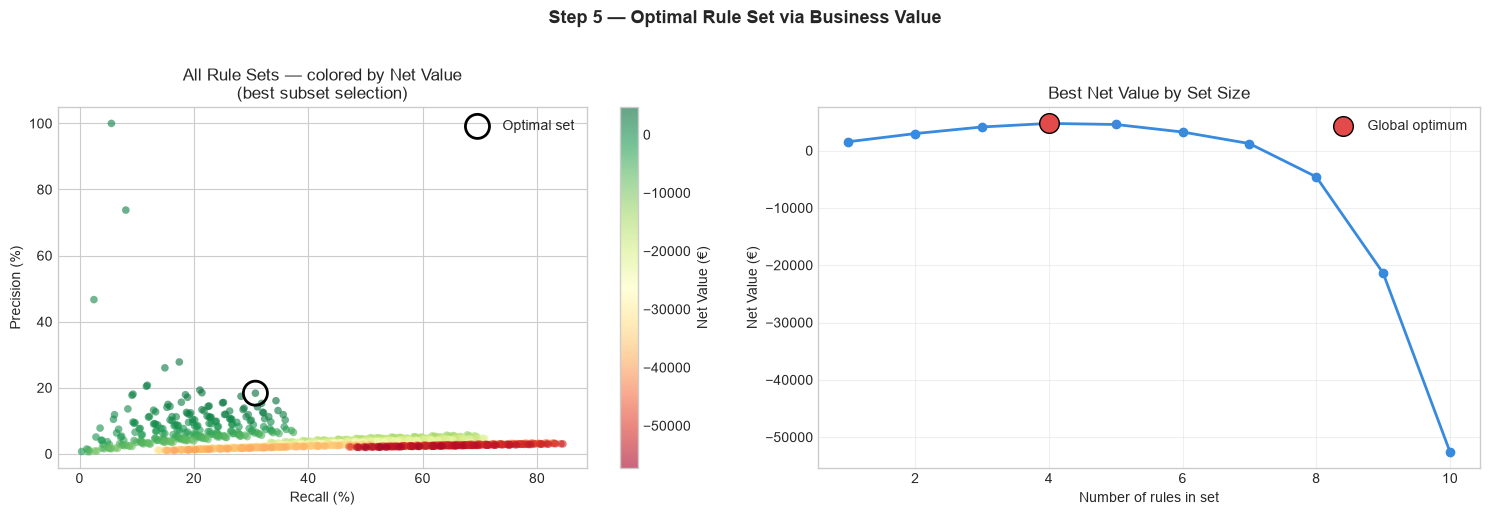

In [12]:
# ==============================================================================
# Step 5: Optimal rule set via best subset selection + business value
# ==============================================================================
# Greedy selection optimized recall alone and produced an undeployable set.
# Here we optimize the real objective — business value — by evaluating EVERY
# possible combination of candidate rules (best subset selection, feasible
# with few rules) and selecting the one that maximizes net value.

from itertools import combinations

# -- Cost model -------------------------------------------------------------- #
AVG_FRAUD_LOSS = 50.0   # € prevented per fraud caught (median ~31€ + handling)
COST_FP = 5.0           # € per false positive (manual review + customer friction)

print(f"Cost model: fraud caught = +{AVG_FRAUD_LOSS:.0f}€, "
      f"false positive = −{COST_FP:.0f}€  (ratio {AVG_FRAUD_LOSS/COST_FP:.0f}:1)\n")

# -- Evaluate all subsets ---------------------------------------------------- #

rule_ids = list(candidates["rule_id"])
y_bool = df["fraud"].values.astype(bool)
total_fraud = int(y_bool.sum())

subset_results = []
for r in range(1, len(rule_ids) + 1):
    for combo in combinations(rule_ids, r):
        combined = np.zeros(len(df), dtype=bool)
        for rid in combo:
            combined |= rule_masks[rid]
        tp = int((combined & y_bool).sum())
        fp = int((combined & ~y_bool).sum())
        nv = tp * AVG_FRAUD_LOSS - fp * COST_FP
        subset_results.append({
            "rules": " + ".join(combo),
            "size": len(combo),
            "tp": tp,
            "fp": fp,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
            "recall": tp / total_fraud,
            "net_value": nv,
        })

subset_df = pd.DataFrame(subset_results).sort_values(
    "net_value", ascending=False
).reset_index(drop=True)

print(f"Combinations evaluated: {len(subset_df):,}\n")

# -- Top sets by net value --------------------------------------------------- #
display(
    subset_df.head(10)
    .style.format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "net_value": "{:,.0f}€",
        "tp": "{:,}",
        "fp": "{:,}",
    })
    .set_caption("Top 10 rule sets by Net Value (best subset selection)")
)

# -- The optimal set --------------------------------------------------------- #
optimal = subset_df.iloc[0]
print("OPTIMAL RULE SET (max Net Value):")
print(f"  Rules: {optimal['rules']}")
print(f"  Net Value: {optimal['net_value']:,.0f}€")
print(f"  Precision: {optimal['precision']:.1%} | Recall: {optimal['recall']:.1%}")
print(f"  Catches {optimal['tp']} fraud, {optimal['fp']:,} false positives")

# -- Comparison: greedy full set vs optimal subset --------------------------- #
greedy_final = seq_df.iloc[-1]
greedy_nv = greedy_final["caught"] * AVG_FRAUD_LOSS - greedy_final["fp"] * COST_FP
print(f"\nGreedy full set (all rules): Net Value {greedy_nv:,.0f}€ "
      f"(precision {greedy_final['precision']:.1%}, recall {greedy_final['recall']:.1%})")
print(f"Best subset improves Net Value by {optimal['net_value'] - greedy_nv:,.0f}€")
print("→ The optimal set excludes broad, noisy rules whose false-positive")
print("  cost exceeds the value of the fraud they catch.")

# -- Visualisation ----------------------------------------------------------- #
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: all subsets in precision-recall, colored by net value
ax = axes[0]
sc = ax.scatter(subset_df["recall"] * 100, subset_df["precision"] * 100,
                c=subset_df["net_value"], cmap="RdYlGn",
                s=30, alpha=0.6, edgecolors="none")
ax.scatter(optimal["recall"] * 100, optimal["precision"] * 100,
           s=300, facecolors="none", edgecolors="black", linewidth=2,
           label="Optimal set", zorder=5)
plt.colorbar(sc, ax=ax, label="Net Value (€)")
ax.set_xlabel("Recall (%)")
ax.set_ylabel("Precision (%)")
ax.set_title("All Rule Sets — colored by Net Value\n(best subset selection)")
ax.legend()

# Right: net value vs set size
ax = axes[1]
best_per_size = subset_df.loc[subset_df.groupby("size")["net_value"].idxmax()]
ax.plot(best_per_size["size"], best_per_size["net_value"],
        marker="o", color="#378ADD", lw=2)
ax.scatter(optimal["size"], optimal["net_value"],
           s=200, color="#E24B4A", edgecolors="black", zorder=5,
           label="Global optimum")
ax.set_xlabel("Number of rules in set")
ax.set_ylabel("Net Value (€)")
ax.set_title("Best Net Value by Set Size")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Step 5 — Optimal Rule Set via Business Value",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/step5_optimal_subset.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 6: From rules to actions (Block / Alert / Shadow)

The assignment asks to *disallow* high-risk events — but not every rule
should auto-block. The action depends on the rule's precision and the cost
of being wrong:

- **High precision** → auto-block. False positives are rare, blocking is safe.
- **Moderate precision** → alert for manual review. Auto-blocking would
  friction too many legitimate customers; a human confirms first.
- **Low / uncertain precision** → shadow mode. The rule runs but doesn't
  block; we observe real performance before activating it.

This reflects operational reality: no fraud team auto-blocks on a 13%-precision
rule. A graduated response (block / alert / shadow) balances fraud prevention
against customer friction — especially critical for new customers at onboarding,
where a wrongful block loses the customer entirely.

In [13]:
# ==============================================================================
# Step 6: Action assignment — Block / Alert / Shadow
# ==============================================================================

# -- Colour helper for the decision table ------------------------------------ #
def color_action(val):
    if "Block" in val:
        return "background-color:#cce5ff" if "monitor" in val else "background-color:#d4edda"
    if "Alert" in val:
        return "background-color:#fff3cd"
    if "Shadow" in val:
        return "background-color:#e2e3e5"
    if "Discard" in val:
        return "background-color:#f8d7da"
    return ""

# -- Decision thresholds ----------------------------------------------------- #
BLOCK_PRECISION = 0.40   # auto-block above this precision
ALERT_PRECISION = 0.05   # alert+review between alert and block thresholds

# Build the action table from the optimal rule set
optimal_rule_ids = optimal["rules"].split(" + ")
action_rows = []

for rid in optimal_rule_ids:
    r = candidates[candidates["rule_id"] == rid].iloc[0]
    nv = r["caught"] * AVG_FRAUD_LOSS - r["fp"] * COST_FP

    if nv <= 0:
        action = "Discard"
        rationale = "FP cost exceeds fraud value"
    elif r["precision"] >= BLOCK_PRECISION:
        action = "Block"
        rationale = f"High precision ({r['precision']:.0%}), safe to auto-block"
    elif r["precision"] >= ALERT_PRECISION:
        action = "Alert + review"
        rationale = f"Moderate precision ({r['precision']:.0%}), human check first"
    else:
        action = "Shadow"
        rationale = "Low precision, observe before activating"

    action_rows.append({
        "rule_id": rid,
        "rule_text": r["rule_text"],
        "precision": r["precision"],
        "recall": r["recall"],
        "caught": r["caught"],
        "fp": r["fp"],
        "net_value": nv,
        "action": action,
        "rationale": rationale,
    })

action_df = pd.DataFrame(action_rows).sort_values("net_value", ascending=False)

# ── Integrate pattern stability into the decision table ──────────────────────
# Uses stability_df from the robustness check (computed after Step 3).
# Cross-references each deployed rule's pattern against its cross-config stability.

stability_lookup = dict(zip(stability_df["pattern"], stability_df["n_configs"]))

def get_stability(rid):
    conditions = candidates[candidates["rule_id"] == rid].iloc[0]["conditions"]
    sig = rule_signature(conditions)
    n = stability_lookup.get(sig, 0)
    return f"{n}/{len(N_SAMPLES)}"

action_df["stability"] = action_df["rule_id"].apply(get_stability)

# Refine action: a high-precision but low-stability rule warrants caution
def refine_action(row):
    n_configs = int(row["stability"].split("/")[0])
    if row["action"] == "Block" and n_configs < 3:
        return "Block (monitor)"   # precise but less stable — watch closely
    return row["action"]

action_df["final_action"] = action_df.apply(refine_action, axis=1)

# -- Final decision table with stability ------------------------------------- #
display(
    action_df[["rule_id", "rule_text", "precision", "recall",
               "net_value", "stability", "final_action"]]
    .style
    .map(color_action, subset=["final_action"])
    .format({
        "precision": "{:.1%}",
        "recall": "{:.1%}",
        "net_value": "{:,.0f}€",
    })
    .set_caption("Final decision table — action informed by precision, "
                 "Net Value, and pattern stability")
)

print("Action logic now combines three signals:")
print("  • Precision    → can we auto-block, or do we need review?")
print("  • Net Value    → is the rule economically positive?")
print("  • Stability    → does the pattern hold across configurations?")
print("\nA precise but unstable rule (e.g. high precision, 2/5 stability)")
print("is flagged 'Block (monitor)' rather than blindly auto-blocked.")

,rule_id,rule_text,precision,recall,net_value,stability,final_action
0,R1,wallet_age <= 52 AND pay_count_90d > 47 AND hi_risk_region > 0,100.0%,5.6%,"1,550€",4/5,Block
2,R3,hi_risk_bank > 0 AND wallet_age <= 52 AND hi_risk_region <= 0,18.1%,9.4%,"1,420€",2/5,Alert + review
3,R4,wallet_age <= 52 AND pay_count_90d <= 47 AND hi_risk_region > 0,12.7%,13.3%,"1,155€",4/5,Alert + review
1,R2,52 < wallet_age <= 228 AND pay_count_90d > 62 AND hi_risk_region > 0,46.7%,2.5%,620€,2/5,Block (monitor)


Action logic now combines three signals:
  • Precision    → can we auto-block, or do we need review?
  • Net Value    → is the rule economically positive?
  • Stability    → does the pattern hold across configurations?

A precise but unstable rule (e.g. high precision, 2/5 stability)
is flagged 'Block (monitor)' rather than blindly auto-blocked.
